# Analisis Exloratorio de Datos (EDA)

### Imports y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from scipy.stats import spearmanr

In [2]:
sns.set_theme(style="ticks", palette="mako")

In [3]:
df = pd.read_csv('/workspace/data/raw/screen_time_mental_health.csv')

### Descriptivo Inicial y Calidad de los Datos

In [4]:
df.shape

(4810, 10)

In [5]:
df.head()

,subject_id,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4810 entries, 0 to 4809
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   subject_id                4810 non-null   int64  
 1   sex                       4810 non-null   str    
 2   screen_time_index         4810 non-null   float64
 3   est_leisure_screen_hours  4810 non-null   float64
 4   sleep_quality_index       4810 non-null   float64
 5   avg_sleep_hours           4810 non-null   float64
 6   midsleep_weekend_hours    4810 non-null   float64
 7   social_jetlag_hours       4810 non-null   float64
 8   bdi_total                 4810 non-null   int64  
 9   depressed                 4810 non-null   int64  
dtypes: float64(6), int64(3), str(1)
memory usage: 375.9 KB


In [7]:
print("\nNulos por columna:\n")
print(df.isnull().sum())


Nulos por columna:

subject_id                  0
sex                         0
screen_time_index           0
est_leisure_screen_hours    0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
bdi_total                   0
depressed                   0
dtype: int64


In [8]:
print("\nDuplicados en subject_id:", df['subject_id'].duplicated().sum())


Duplicados en subject_id: 0


In [9]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
subject_id,4810.0,2405.50,1388.67,1.00,1203.25,2405.50,3607.75,4810.00
screen_time_index,4810.0,3.22,1.03,1.00,2.33,3.00,4.00,6.00
est_leisure_screen_hours,4810.0,3.96,2.39,0.50,2.07,3.50,5.50,10.00
sleep_quality_index,4810.0,1.90,0.85,1.00,1.25,1.75,2.25,6.00
avg_sleep_hours,4810.0,7.69,1.27,1.36,7.05,7.87,8.54,12.21
midsleep_weekend_hours,4810.0,5.57,1.42,1.67,4.54,5.42,6.50,10.50
social_jetlag_hours,4810.0,2.40,1.14,-3.03,1.58,2.29,3.12,6.96
bdi_total,4810.0,7.27,7.70,0.00,2.00,5.00,10.00,51.00
depressed,4810.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00


El dataset contiene 4.810 registros y 10 columnas, sin valores nulos ni duplicados en `subject_id`, lo que confirma que se trata de un dataset listo para análisis. Tenemos que `avg_sleep_hours` tiene una media de 7.69h con asimetría negativa (skew -0.92), reflejando un grupo que duerme muy poco y arrastra la distribución hacia la izquierda, con un mínimo de 1.36h que es clínicamente extremo y candidato a revisión como outlier; y que `social_jetlag_hours` presenta un mínimo negativo (-3.03), un valor atípico que conviene decidir si tratar como dato válido o como posible error de captura antes de avanzar. Además, varias variables ya muestran asimetría notable (`sleep_quality_index` con skew 1.47, `est_leisure_screen_hours` con 0.87), lo que anticipa colas largas en las distribuciones y sugiere priorizar la mediana sobre la media al resumir estas variables en las siguientes secciones.

### Analisis de las Variables Targets

**Depressed**

In [10]:
print(df['depressed'].value_counts(normalize=True).round(3) * 100)

depressed
0    83.6
1    16.4
Name: proportion, dtype: float64


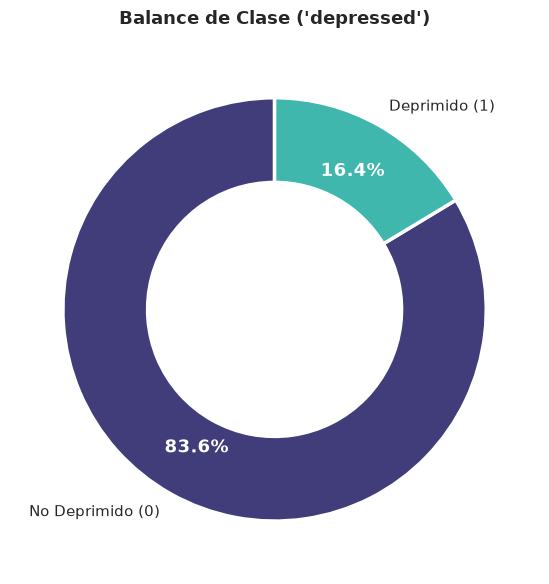

In [11]:
# 2. Seleccionar 2 tonos con alto contraste dentro de 'mako'
mako_colors = [
    sns.color_palette("mako", 6)[1],
    sns.color_palette("mako", 6)[4],
]

# 3. Crear el gráfico de dona
fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    df["depressed"].value_counts(normalize=True) * 100,
    labels=["No Deprimido (0)", "Deprimido (1)"],
    colors=mako_colors,
    autopct="%.1f%%",
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2.5),
)

# 4. Estilizar los porcentajes dentro de los anillos
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_weight("bold")
    autotext.set_fontsize(13)

plt.title("Balance de Clase ('depressed')", fontsize=13, pad=15, weight="bold")
plt.tight_layout()
plt.show()

**bdi_total**

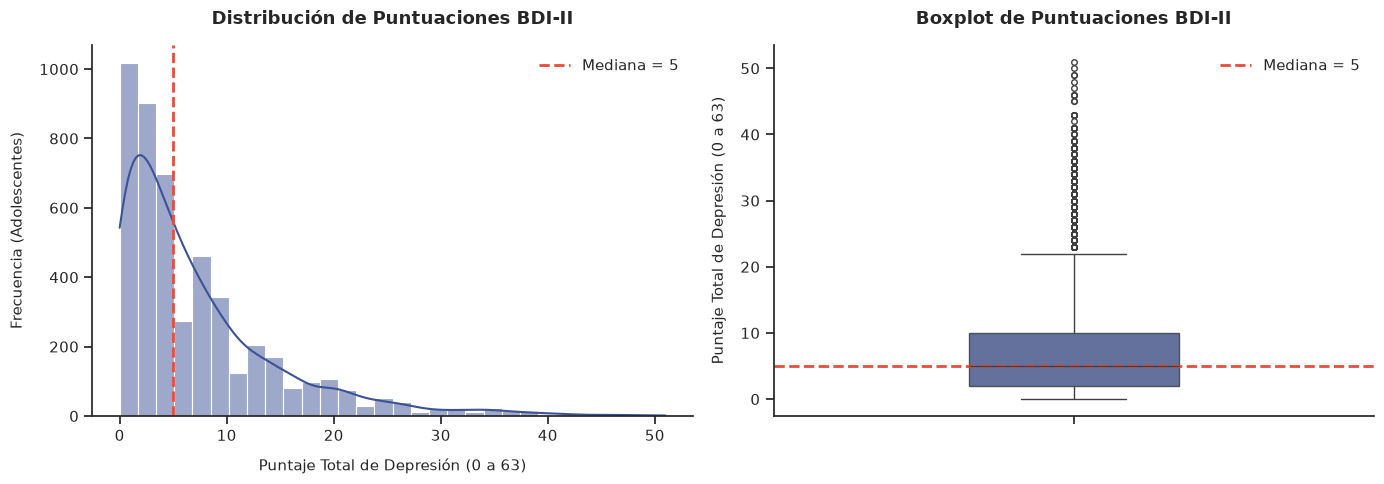

In [12]:
mako_main = sns.color_palette("mako", 10)[3]
mediana = df["bdi_total"].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Histograma + KDE ---
sns.histplot(
    df["bdi_total"], bins=30, kde=True, ax=ax1,
    color=mako_main, edgecolor="white", linewidth=0.8,
)
ax1.axvline(mediana, color="#E74C3C", linestyle="--", linewidth=2, label=f"Mediana = {mediana:.0f}")
ax1.set_title("Distribución de Puntuaciones BDI-II", fontsize=13, pad=15, fontweight="bold")
ax1.set_xlabel("Puntaje Total de Depresión (0 a 63)", fontsize=11, labelpad=10)
ax1.set_ylabel("Frecuencia (Adolescentes)", fontsize=11, labelpad=10)
ax1.legend(frameon=True, facecolor="white", edgecolor="none")

# --- Gráfico 2: Boxplot ---
sns.boxplot(
    y=df["bdi_total"], ax=ax2,
    color=mako_main, width=0.35, fliersize=4,
    boxprops=dict(alpha=0.85),
)
ax2.axhline(mediana, color="#E74C3C", linestyle="--", linewidth=2, label=f"Mediana = {mediana:.0f}")
ax2.set_title("Boxplot de Puntuaciones BDI-II", fontsize=13, pad=15, fontweight="bold")
ax2.set_ylabel("Puntaje Total de Depresión (0 a 63)", fontsize=11, labelpad=10)
ax2.legend(frameon=True, facecolor="white", edgecolor="none")

sns.despine(ax=ax1, top=True, right=True)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.show()

**`bdi_total`** presenta una distribución fuertemente sesgada a la derecha (skew 1.89, mediana 5, media 7.27): la mayoría de los adolescentes reporta síntomas mínimos o nulos, y una minoría concentra puntajes altos, generando la cola larga de outliers que se ve en el boxplot.

**`depressed`** es una simplificación de `bdi_total` mediante el corte clínico ≥14. Al binarizar se pierde granularidad (un adolescente con 14 y otro con 51 quedan en la misma categoría "1"), pero se gana interpretabilidad clínica directa y es el formato natural si el objetivo final es clasificación. Tenemos un claro desbalance de clase lo cual nos lleva plantearnos la idea de usar metodos de balanceo para los algoritmos de clasificación.

### Analisis de Variables Categoricas

In [13]:
print(df['sex'].value_counts())

sex
Boy     2446
Girl    2364
Name: count, dtype: int64


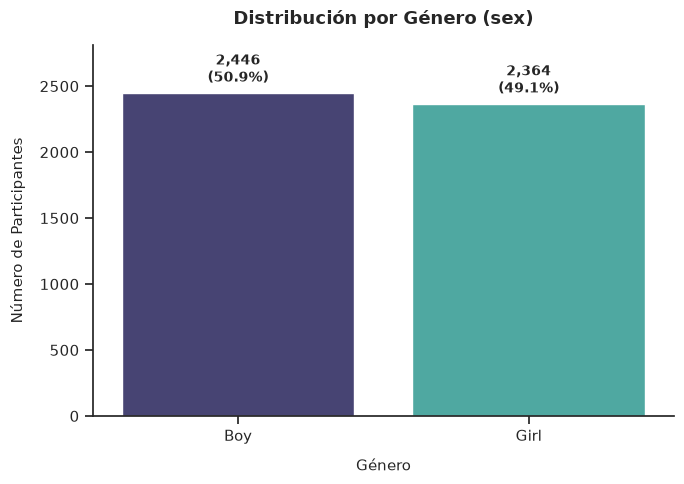

In [14]:
mako_colors = [
    sns.color_palette("mako", 6)[1],
    sns.color_palette("mako", 6)[4],
]

# Crear figura independiente
fig, ax = plt.subplots(figsize=(7, 5))

# Gráfico de recuento sin advertencias de deprecación
ax = sns.countplot(
    data=df,
    x="sex",
    hue="sex",
    palette=mako_colors,
    legend=False,
    ax=ax,
    order=df["sex"].value_counts().index,
)

# Anotación con recuento y porcentaje en cada barra
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = (count / total) * 100
    ax.annotate(
        f"{count:,}\n({percentage:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, count),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
        fontweight="bold",
        fontsize=10,
    )

# Estilizado de títulos y ejes
ax.set_title(
    "Distribución por Género (sex)", fontsize=13, pad=15, fontweight="bold"
)
ax.set_xlabel("Género", fontsize=11, labelpad=10)
ax.set_ylabel("Número de Participantes", fontsize=11, labelpad=10)

# Ajuste de límite superior en Y
ax.set_ylim(0, max(df["sex"].value_counts()) * 1.15)

# Limpieza visual académica
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

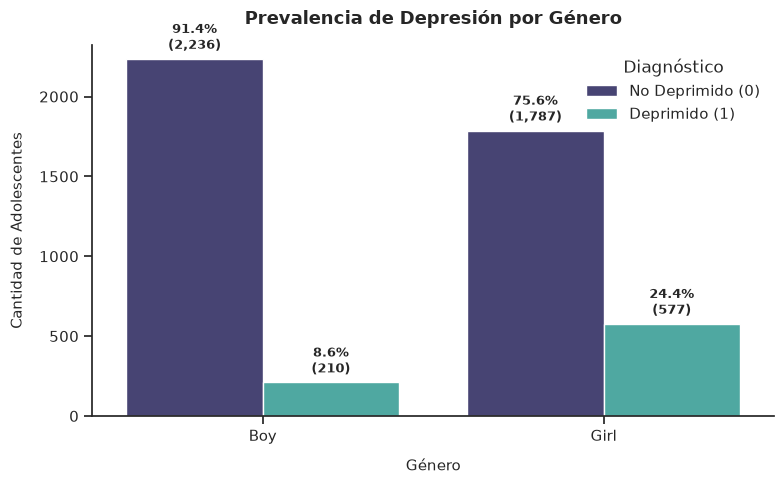

In [15]:
mako_colors = [
    sns.color_palette("mako", 6)[1],
    sns.color_palette("mako", 6)[4],
]

fig, ax = plt.subplots(figsize=(8, 5))

# Gráfico de recuento agrupado por sexo
ax = sns.countplot(
    data=df,
    x="sex",
    hue="depressed",
    palette=mako_colors,
    ax=ax,
    order=df["sex"].value_counts().index,
)

# Calcular y anotar porcentajes dentro de cada grupo de sexo
sex_counts = df["sex"].value_counts()

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        # Identificar la categoría de sexo correspondiente x (0 o 1)
        x_idx = int(round(p.get_x() + p.get_width() / 2.0))
        sex_cat = df["sex"].value_counts().index[x_idx]
        total_group = sex_counts[sex_cat]

        percentage = (height / total_group) * 100
        ax.annotate(
            f"{percentage:.1f}%\n({int(height):,})",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontweight="bold",
            fontsize=9.5,
        )

# Títulos y etiquetas
ax.set_title(
    "Prevalencia de Depresión por Género", fontsize=13, pad=15, fontweight="bold"
)
ax.set_xlabel("Género", fontsize=11, labelpad=10)
ax.set_ylabel("Cantidad de Adolescentes", fontsize=11, labelpad=10)

# Leyenda sobria
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["No Deprimido (0)", "Deprimido (1)"],
    title="Diagnóstico",
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

# Ajuste de espacio vertical
ax.set_ylim(0, max(sex_counts) * 0.95)

sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

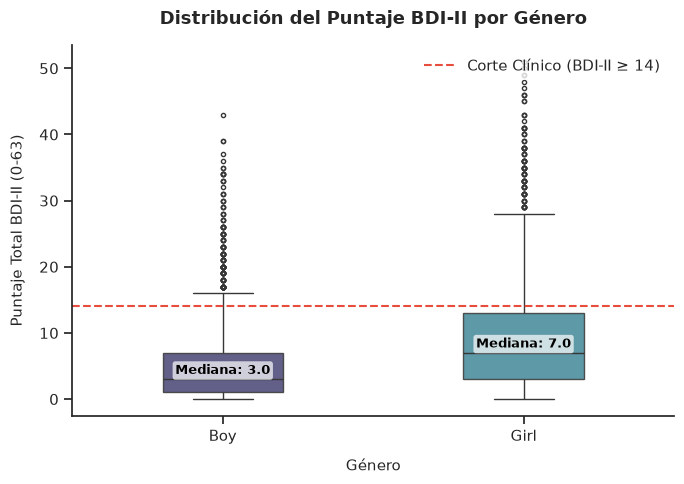

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

gender_colors = [
    sns.color_palette("mako", 6)[1],
    sns.color_palette("mako", 6)[3],
]

# Boxplot
sns.boxplot(
    data=df,
    x="sex",
    y="bdi_total",
    hue="sex",
    palette=gender_colors,
    legend=False,
    width=0.4,
    fliersize=3,
    ax=ax,
    boxprops=dict(alpha=0.85),
)

# Línea de umbral clínico BDI >= 14
ax.axhline(
    14,
    color="#E74C3C",
    linestyle="--",
    linewidth=1.5,
    label="Corte Clínico (BDI-II ≥ 14)",
)

# Anotación de medianas exactas
medians = df.groupby("sex")["bdi_total"].median()
for idx, (sex_val, med_val) in enumerate(medians.items()):
    ax.text(
        idx,
        med_val + 0.8,
        f"Mediana: {med_val:.1f}",
        horizontalalignment="center",
        size=9.5,
        color="black",
        weight="bold",
        bbox=dict(
            boxstyle="round,pad=0.2", facecolor="white", alpha=0.7, edgecolor="none"
        ),
    )

ax.set_title(
    "Distribución del Puntaje BDI-II por Género",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
ax.set_xlabel("Género", fontsize=11, labelpad=10)
ax.set_ylabel("Puntaje Total BDI-II (0-63)", fontsize=11, labelpad=10)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")

sns.despine(top=True, right=True)
plt.tight_layout()

plt.show()

**Distribución balanceada por género:** la muestra está prácticamente balanceada (50.9% Boy vs 49.1% Girl).

**Prevalencia de depresión por género:** Las chicas tienen una tasa de depresión de 24.4%, casi **3 veces más** que los chicos que es 8.6%. Esto es un indicio claro de que `sex` oculta una señal fuerte para predicción.

**El Boxplot de BDI-II por género:** confirma y cuantifica lo anterior en la escala continua. La mediana de las chicas (7.0) es más del doble que la de los chicos (3.0), y las medias siguen el mismo patrón (9.40 vs 5.22). La caja de "Girl" está desplazada hacia arriba y es visiblemente más ancha lo cual puede indicar síntomas más heterogéneos dentro del grupo. Ambos grupos muestran la misma cola larga de outliers hacia arriba, pero la mediana de "Girl" ya está bastante más cerca del corte clínico (14) que la de "Boy". 

**En conjunto**, el género parece ser uno de los factores más fuertes asociados a `depressed`/`bdi_total` en este dataset.

### Analisis de Variables Númericas

**Distribuciones**

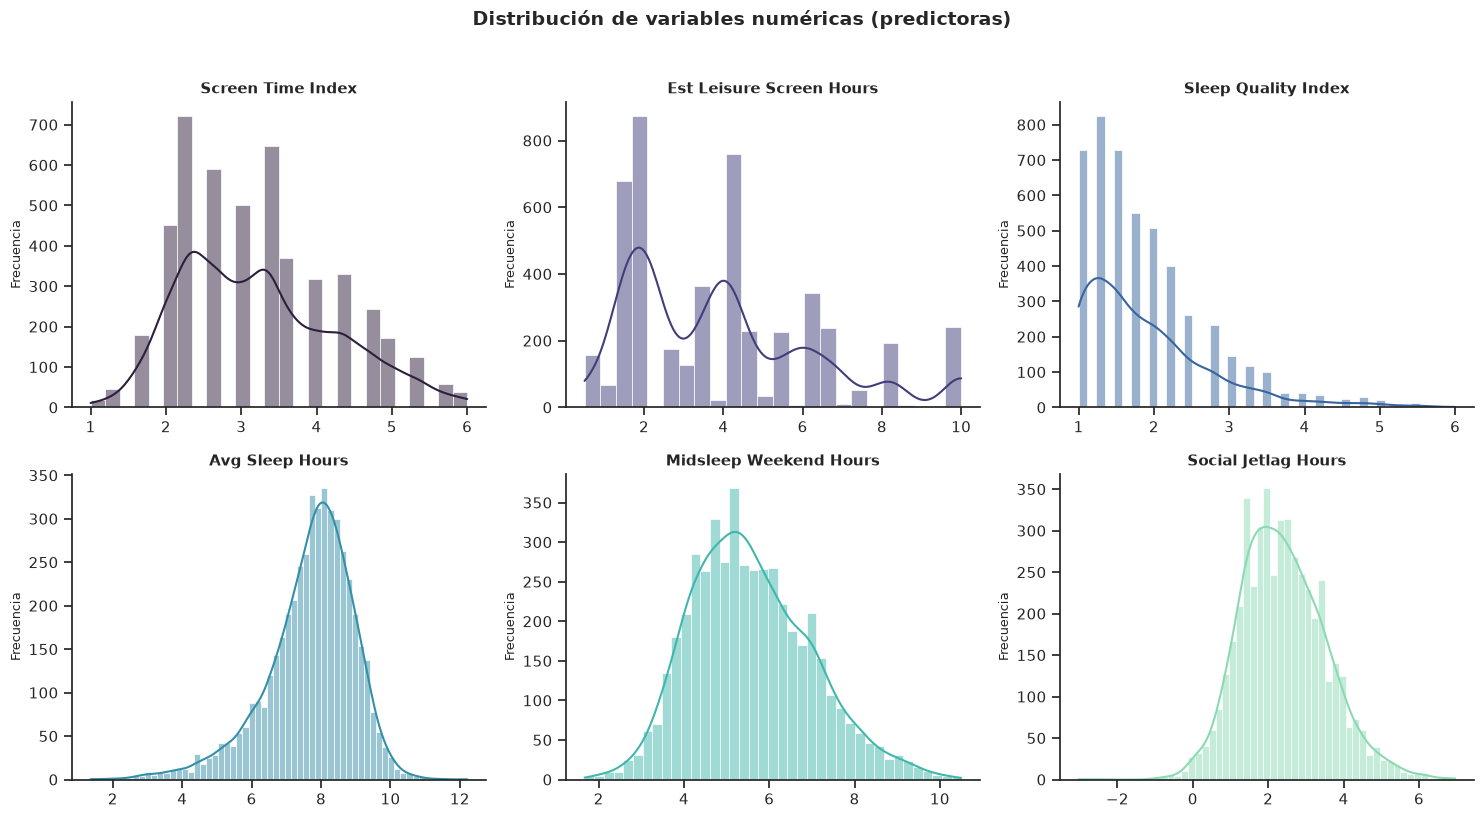

In [17]:
cols = [
    'screen_time_index', 'est_leisure_screen_hours', 'sleep_quality_index',
    'avg_sleep_hours', 'midsleep_weekend_hours', 'social_jetlag_hours'
]

mako_palette = sns.color_palette("mako", len(cols))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (ax, col) in enumerate(zip(axes.flat, cols)):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=ax,
        color=mako_palette[i],
        edgecolor="white",
        linewidth=0.5
    )
    
    clean_title = col.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia", fontsize=9)

sns.despine()
plt.suptitle("Distribución de variables numéricas (predictoras)", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

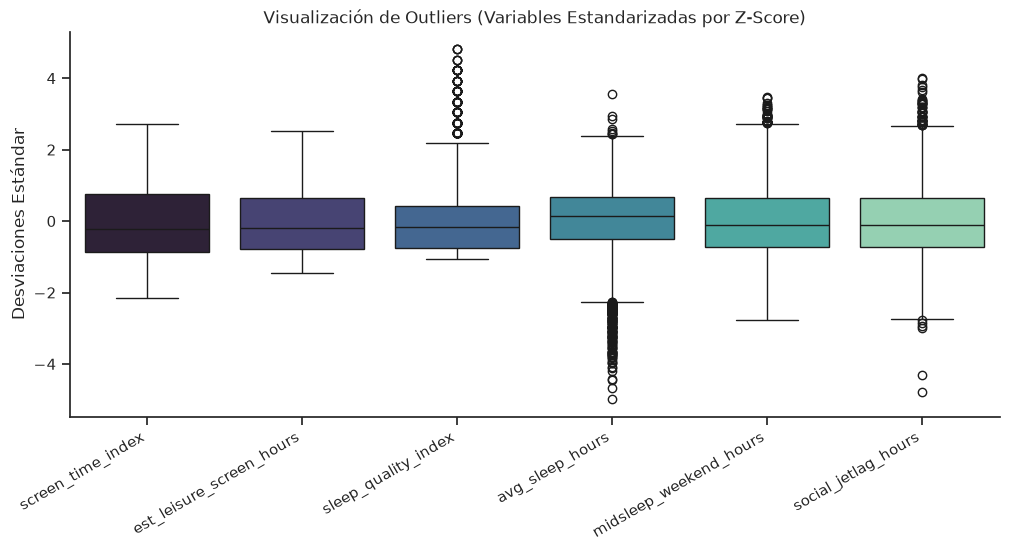

In [18]:
plt.figure(figsize=(12, 5))
df_z = df[cols].apply(zscore)
sns.boxplot(data=df_z, palette="mako")
plt.xticks(rotation=30, ha='right')
plt.title("Visualización de Outliers (Variables Estandarizadas por Z-Score)")
plt.ylabel("Desviaciones Estándar")
sns.despine()
plt.show()

Distribuciones por Sexo

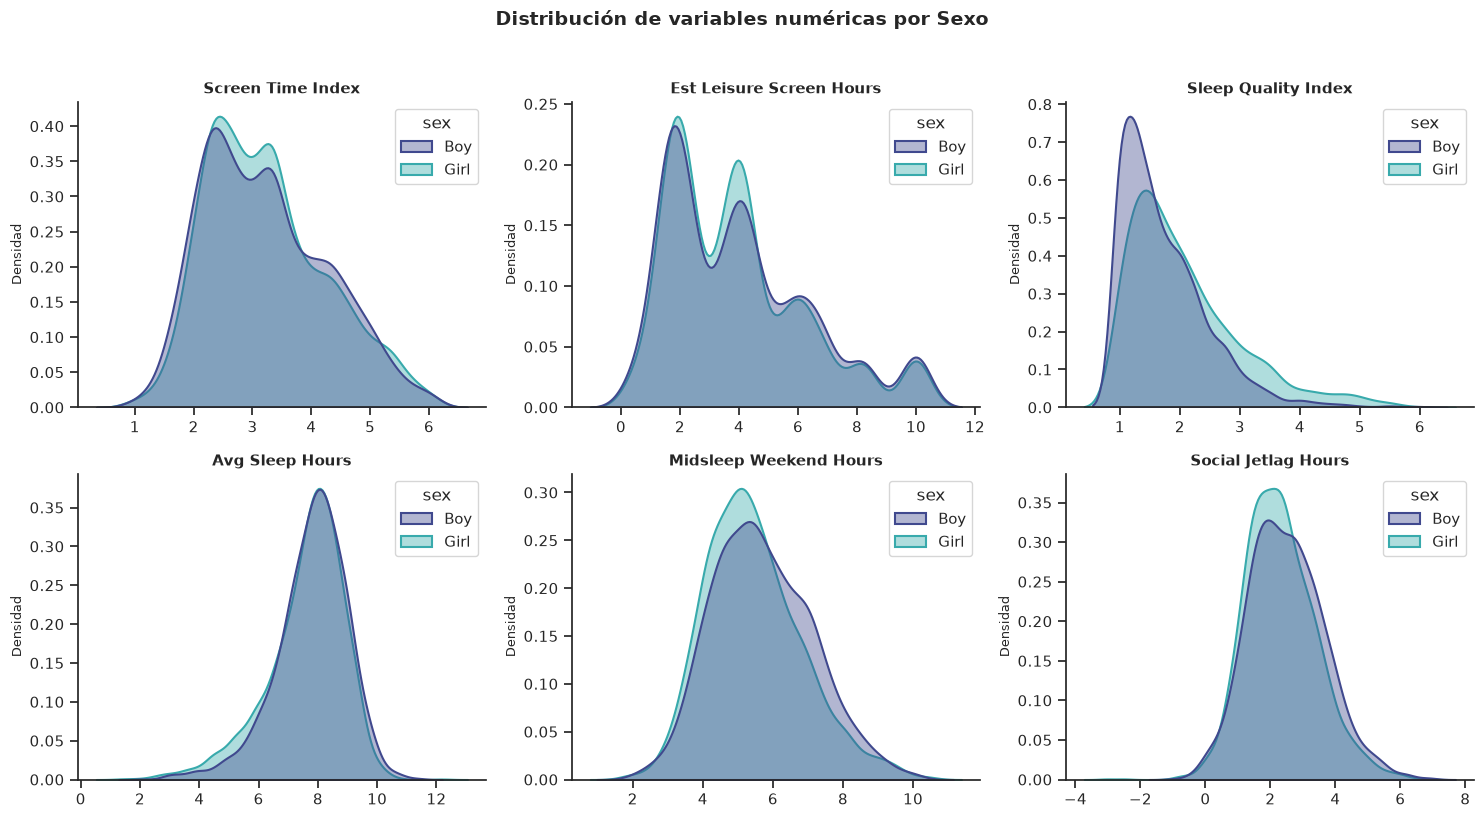

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="sex",
        fill=True,
        common_norm=False,  # Normaliza cada grupo de forma independiente
        palette="mako",
        alpha=0.4,
        linewidth=1.5,
        ax=ax
    )
    clean_title = col.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Densidad", fontsize=9)

sns.despine()
plt.suptitle("Distribución de variables numéricas por Sexo", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


**Distribuciones por sexo:** las curvas de Boy y Girl se solapan casi por completo en las diferentes variables. Esto es un hallazgo importante en conjunto con las imágenes anteriores del género, sugiere que hay factores externos al dataset (hormonales, sociales, u otros no capturados aquí) detrás de la brecha de género en depresión.

Distribuciones por Depresión

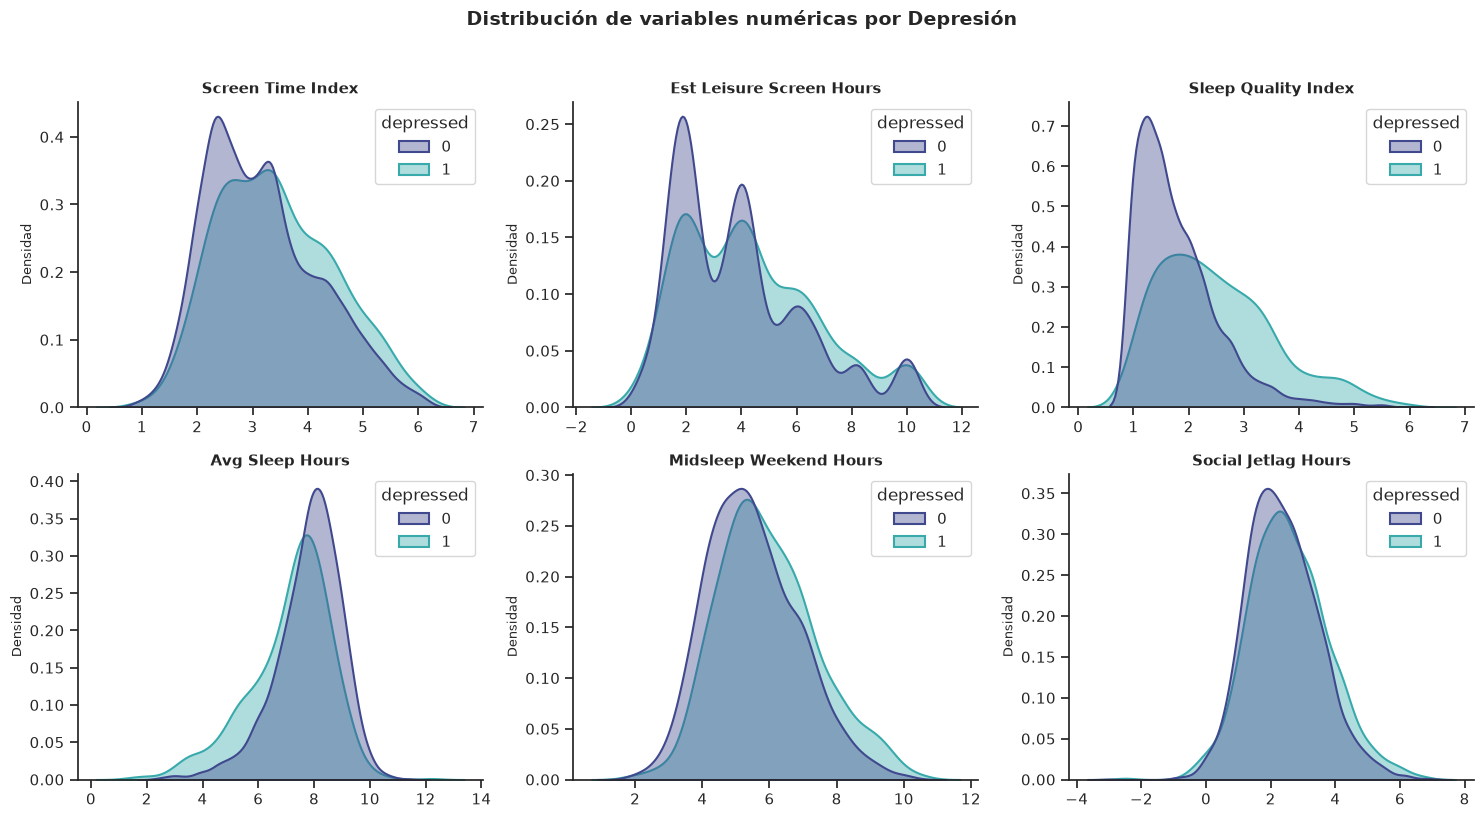

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue="depressed",
        fill=True,
        common_norm=False,
        palette="mako",
        alpha=0.4,
        linewidth=1.5,
        ax=ax
    )
    clean_title = col.replace('_', ' ').title()
    ax.set_title(clean_title, fontsize=11, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Densidad", fontsize=9)

sns.despine()
plt.suptitle("Distribución de variables numéricas por Depresión", fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

**Distribuciones por depresión:** acá sí hay separación visible, especialmente en `sleep_quality_index` (el grupo `depressed=1` está claramente desplazado a la derecha, es decir, peor calidad de sueño) y en menor medida en `screen_time_index` y `est_leisure_screen_hours`. `avg_sleep_hours` muestra al grupo depresivo con una cola más gruesa hacia la izquierda (menos horas). Esto sugiere que `sleep_quality_index` es el predictor con más señal, seguido de `avg_sleep_hours`.

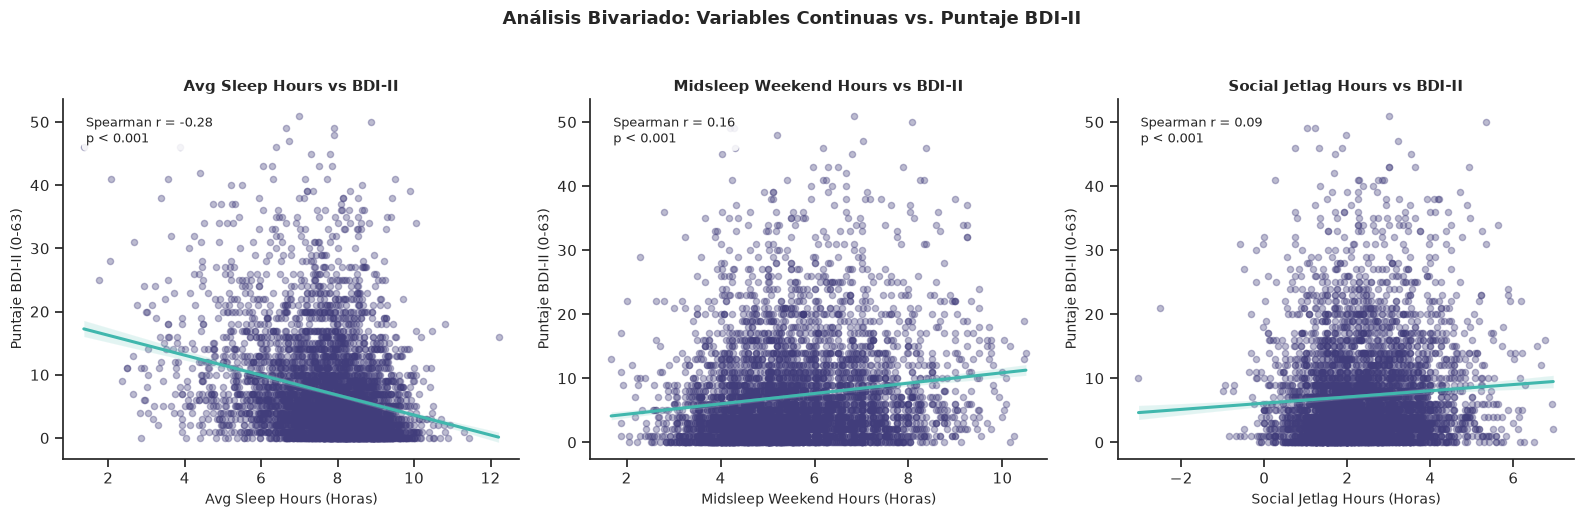

In [21]:
continuous_cols = [
    'avg_sleep_hours',
    'midsleep_weekend_hours',
    'social_jetlag_hours'
]

# Selección de tonos directo de la paleta 'mako'
mako_palette = sns.color_palette("mako", 6)
point_color = mako_palette[1]  # Azul profundo
line_color = mako_palette[4]   # Verde agua brillante para contraste de la línea

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, continuous_cols):
    # 1. Scatterplot con línea de tendencia alineado a la paleta mako
    sns.regplot(
        data=df,
        x=col,
        y="bdi_total",
        ax=ax,
        color=point_color,
        scatter_kws={'alpha': 0.35, 's': 20},
        line_kws={'color': line_color, 'linewidth': 2.2}
    )
    
    # 2. Cálculo e inclusión de la correlación de Spearman
    data_clean = df[[col, "bdi_total"]].dropna()
    if len(data_clean) > 0:
        r, p_val = spearmanr(data_clean[col], data_clean["bdi_total"])
        p_text = "< 0.001" if p_val < 0.001 else f"= {p_val:.3f}"
        
        ax.text(
            0.05, 0.88,
            f"Spearman r = {r:.2f}\np {p_text}",
            transform=ax.transAxes,
            fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="none")
        )
    
    # 3. Formato estético
    clean_title = col.replace('_', ' ').title()
    ax.set_title(f"{clean_title} vs BDI-II", fontsize=11, fontweight='bold')
    ax.set_xlabel(f"{clean_title} (Horas)", fontsize=10)
    ax.set_ylabel("Puntaje BDI-II (0-63)", fontsize=10)

sns.despine()
plt.suptitle("Análisis Bivariado: Variables Continuas vs. Puntaje BDI-II", fontsize=13, y=1.03, fontweight='bold')
plt.tight_layout()
plt.show()

**Bivariado continuo vs BDI-II:** `avg_sleep_hours` tiene la relación más fuerte y negativa (r=-0.28, p<0.001): a más horas de sueño, menor síntoma depresivo, con una pendiente descendente clara. `midsleep_weekend_hours` tiene relación positiva moderada (r=0.16): dormirse más tarde/despertar más tarde el fin de semana se asocia a más síntomas. `social_jetlag_hours` es la más débil de las tres (r=0.09) y puede que su valor predictivo real sea marginal.

**Analisís de Correlación (Spearman)**

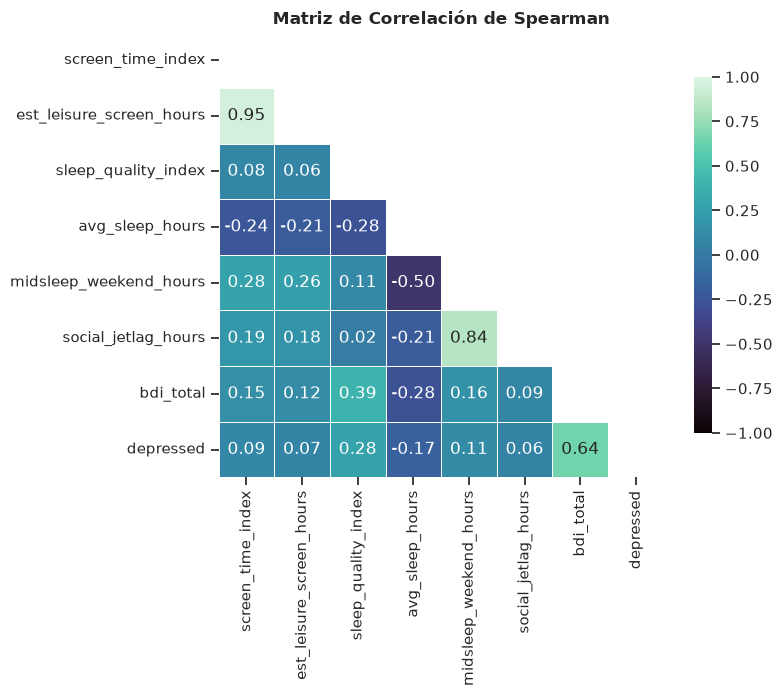

In [22]:
num = df.select_dtypes('number').drop(columns=['subject_id'])

# Matriz mediante correlación de Spearman
corr = num.corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))

# 4. Construcción del mapa de calor
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="mako", 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5, 
    cbar_kws={"shrink": .8}, 
    ax=ax
)

ax.set_title("Matriz de Correlación de Spearman", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Matriz de correlación de Spearman:** `sleep_quality_index` es el predictor individual más fuerte de `bdi_total`. Por otro lado, hay multicolinealidad fuerte entre `screen_time_index`/`est_leisure_screen_hours` (r=0.95) y entre `midsleep_weekend_hours`/`social_jetlag_hours` (r=0.84), no deberían entrar juntas a un modelo lineal.

### Outliers

En general, el sueño (calidad y cantidad) es consistentemente el dominio con mayor relación con la salud mental en estos datos, el tiempo de pantalla tiene una señal mucho más débil, y el género es un factor de riesgo fuerte que actúa independientemente de los hábitos de sueño/pantalla medidos aquí.

In [23]:
def tabla_outliers_iqr(dataframe, columnas):
    resultados = []
    for col in columnas:
        # Calcular cuartiles y IQR
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Definir límites
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        
        # Contar outliers
        outliers = dataframe[(dataframe[col] < limite_inf) | (dataframe[col] > limite_sup)]
        pct_outliers = (len(outliers) / len(dataframe)) * 100
        
        resultados.append({
            'Variable': col,
            'Límite Inferior': round(limite_inf, 2),
            'Límite Superior': round(limite_sup, 2),
            'Total Outliers': len(outliers),
            '% Outliers': round(pct_outliers, 2)
        })
        
    return pd.DataFrame(resultados).sort_values(by='% Outliers', ascending=False)

# Aplicar a nuestras variables numéricas clave
cols_analisis = [
    'bdi_total', 'avg_sleep_hours', 'midsleep_weekend_hours', 
    'social_jetlag_hours', 'est_leisure_screen_hours'
]

resumen_outliers = tabla_outliers_iqr(df, cols_analisis)
display(resumen_outliers)

,Variable,Límite Inferior,Límite Superior,Total Outliers,% Outliers
0,bdi_total,-10.00,22.00,257,5.34
1,avg_sleep_hours,4.82,10.77,164,3.41
3,social_jetlag_hours,-0.73,5.43,54,1.12
2,midsleep_weekend_hours,1.60,9.44,37,0.77
4,est_leisure_screen_hours,-3.08,10.64,0,0.00


In [24]:
# Lista actualizada con sleep_quality_index en lugar de horas de pantalla
variables_analisis = [
    'avg_sleep_hours', 
    'midsleep_weekend_hours', 
    'social_jetlag_hours', 
    'sleep_quality_index'
]

for col in variables_analisis:
    # 1. Calcular límites estadísticos (Método IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    # 2. Filtrar el dataframe original para conservar solo los outliers
    outliers_df = df[(df[col] < limite_inf) | (df[col] > limite_sup)].copy()
    
    # 3. Mostrar ID y la variable, ordenado por el valor anómalo
    if not outliers_df.empty:
        detalle_outliers = outliers_df[['subject_id', col]].sort_values(by=col)
        
        print(f"\n{'='*55}")
        print(f" OUTLIERS EN: {col.upper()}")
        print(f" (Valores < {limite_inf:.2f} o > {limite_sup:.2f}) - Total: {len(detalle_outliers)} casos")
        print(f"{'='*55}")
        
        display(detalle_outliers)
    else:
        print(f"\n{'='*55}")
        print(f" OUTLIERS EN: {col.upper()}")
        print(f" No se detectaron valores atípicos mediante método IQR.")
        print(f"{'='*55}")


 OUTLIERS EN: AVG_SLEEP_HOURS
 (Valores < 4.82 o > 10.77) - Total: 164 casos


,subject_id,avg_sleep_hours
693,694,1.36
4270,4271,1.77
4556,4557,2.05
4357,4358,2.07
4098,4099,2.36
...,...,...
887,888,10.89
3785,3786,10.95
938,939,11.31
2391,2392,11.43



 OUTLIERS EN: MIDSLEEP_WEEKEND_HOURS
 (Valores < 1.60 o > 9.44) - Total: 37 casos


,subject_id,midsleep_weekend_hours
2397,2398,9.46
2141,2142,9.46
2290,2291,9.49
162,163,9.50
2162,2163,9.50
1089,1090,9.50
1499,1500,9.50
2762,2763,9.50
4407,4408,9.50
4511,4512,9.50



 OUTLIERS EN: SOCIAL_JETLAG_HOURS
 (Valores < -0.73 o > 5.43) - Total: 54 casos


,subject_id,social_jetlag_hours
1942,1943,-3.03
3615,3616,-2.50
750,751,-1.00
991,992,-0.95
506,507,-0.86
2735,2736,-0.75
1156,1157,5.46
4492,4493,5.46
4223,4224,5.46
3310,3311,5.50



 OUTLIERS EN: SLEEP_QUALITY_INDEX
 (Valores < -0.25 o > 3.75) - Total: 175 casos


,subject_id,sleep_quality_index
46,47,4.00
262,263,4.00
351,352,4.00
459,460,4.00
632,633,4.00
...,...,...
4526,4527,5.75
1810,1811,5.75
3560,3561,6.00
2876,2877,6.00


Los outliers en variables de sueño están sistemáticamente sobrerrepresentados en el grupo depresivo, reforzando que el sueño es el dominio con más señal clínica del dataset. Para modelado, no pensamos eliminar estos casos. Es preferible, usar métodos robustos (árboles/ensambles) que no se distorsionen por colas largas, en vez de forzar transformaciones agresivas que borrarían justo la señal más relevante. Para regresión hacer transformaciones que hagan las distribuciones mas simetricas.

El Analisis exploratorio muestra que la salud mental adolescente en este dataset está fuertemente ligada a los patrones de sueño (calidad, cantidad y horario). Sorprendentemente el tiempo de pantalla su relación con la depresión resultó débil pese a ser el eje central del dataset. El género también emerge como un factor de peso, las chicas presentan casi 3 veces más depresión que los chicos. A nivel de calidad, el dataset está limpio (sin nulos ni duplicados) pero contiene multicolinealidad relevante entre pares de variables redundantes, y asos extremos concentrados en sueño y en el puntaje BDI que, lejos de ser errores, son justamente los sujetos clínicamente más relevantes, por la cual no deberían eliminarse, sino tratarse con métodos que respeten su naturaleza (transformaciones adecuadas o modelos robustos) al momento de modelar.